# **Airbnb Listings Data Analysis - Edinburgh**

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member  -** Saurabh Patil

# **Project Summary -**

This project analyzes Airbnb listings data for **Edinburgh, Scotland**, sourced from Inside Airbnb (`listings.csv`, 6,258 listings, 19 columns).

The goal is to clean the raw data, explore it thoroughly, and extract insights that answer core business questions: how prices vary by neighbourhood and room type, which areas dominate supply, how reviews and availability relate to pricing, and what patterns exist among hosts.

**Data cleaning** involved dropping two columns that were unusable - `neighbourhood_group` (100% missing) and `license` (70% missing) - imputing the 634 missing `price` values with the median, and filling missing `reviews_per_month` with 0 for listings that have never been reviewed. `last_review` was converted to a proper datetime. No duplicate rows or listing IDs were found.

**Exploratory analysis** covered univariate distributions (price, room type, availability, minimum nights), bivariate relationships (price vs. room type, price vs. reviews, price vs. neighbourhood), and multivariate views (correlation heatmap, pair plots, and a geographic price map).

Key findings: **Entire home/apt** listings dominate supply (71%) and command roughly double the price of **private rooms**. The **Old Town, Princes Street and Leith Street** area has by far the most listings (753, ~12% of the market) and among the highest median prices, confirming it as the primary tourist/short-let hub. Price shows weak correlation with number of reviews, meaning popularity (measured by reviews) is not primarily driven by price - cheaper listings are not necessarily reviewed more, and premium listings are not being filtered out by guests. A small group of multi-listing hosts (commercial operators) manages a disproportionate share of inventory.

The notebook closes with concrete recommendations for both Airbnb (as a platform) and individual hosts on pricing and positioning strategy.

# **GitHub Link -**

### https://github.com/Saurabhp8501/

# **Problem Statement**

Short-term rental hosts and Airbnb (the platform) both need to understand what drives pricing and demand in a given city to make better decisions — hosts on how to price and position their listing, and the platform on how to guide new hosts and manage supply.

Using the Edinburgh listings dataset, this notebook explores how **price**, **room type**, **location (neighbourhood)**, **reviews**, and **availability** interact, in order to answer: *what makes a listing successful, and where are the biggest opportunities/risks in the current market?*

#### **Define Your Business Objective?**

To identify the key drivers of Airbnb listing price and demand in Edinburgh, and translate those drivers into actionable recommendations that (a) help hosts price and position their listings more effectively, and (b) help Airbnb identify under/over-served neighbourhoods and room types.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('listings.csv')

### Dataset First View

In [3]:
# Dataset First Look
df.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,15420,Georgian Boutique Apt City Centre,60423.0,1.462508e+18,Charlotte,NaN,"Old Town, Princes Street and Leith Street",55.957590,-3.188050,Entire home/apt,226.0,2.0,704,2026-06-28,3.74,1.0,28,73,EH-68481-F
1,24288,"Cool central Loft, sleeps 4, 2 double bed+en-s...",46498.0,1.462508e+18,Gordon,NaN,"Canongate, Southside and Dumbiedykes",55.944983,-3.185293,Entire home/apt,202.0,3.0,433,2026-06-07,2.26,1.0,176,46,NaN
2,38628,Edinburgh Holiday Let,165635.0,1.462511e+18,Trish,NaN,Joppa,55.942150,-3.096400,Entire home/apt,129.0,1.0,76,2026-05-25,0.52,1.0,258,1,EH-70886-F
3,48645,Large sunny room on Royal Mile,221474.0,1.462511e+18,Mark,NaN,"Canongate, Southside and Dumbiedykes",55.950720,-3.183050,Private room,220.0,1.0,1157,2026-06-20,6.17,1.0,109,47,EH-70355-F
4,51505,Superb City Centre Apartment,236828.0,1.462513e+18,Francois,NaN,New Town West,55.954800,-3.196410,Entire home/apt,356.0,2.0,156,2026-05-29,0.82,12.0,28,35,NaN


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 6258
Columns: 19


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6258 entries, 0 to 6257
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              6258 non-null   int64  
 1   name                            6258 non-null   str    
 2   host_id                         6244 non-null   float64
 3   host_profile_id                 6243 non-null   float64
 4   host_name                       6238 non-null   str    
 5   neighbourhood_group             0 non-null      float64
 6   neighbourhood                   6258 non-null   str    
 7   latitude                        6258 non-null   float64
 8   longitude                       6258 non-null   float64
 9   room_type                       6258 non-null   str    
 10  price                           5624 non-null   float64
 11  minimum_nights                  6256 non-null   float64
 12  number_of_reviews               6258 non-null

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print("Fully duplicate rows:", df.duplicated().sum())
print("Duplicate listing IDs:", df['id'].duplicated().sum())

Fully duplicate rows: 0
Duplicate listing IDs: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
neighbourhood_group,6258,100.00
license,4394,70.21
reviews_per_month,668,10.67
last_review,668,10.67
price,634,10.13
host_name,20,0.32
host_profile_id,15,0.24
host_id,14,0.22
calculated_host_listings_count,14,0.22
minimum_nights,2,0.03


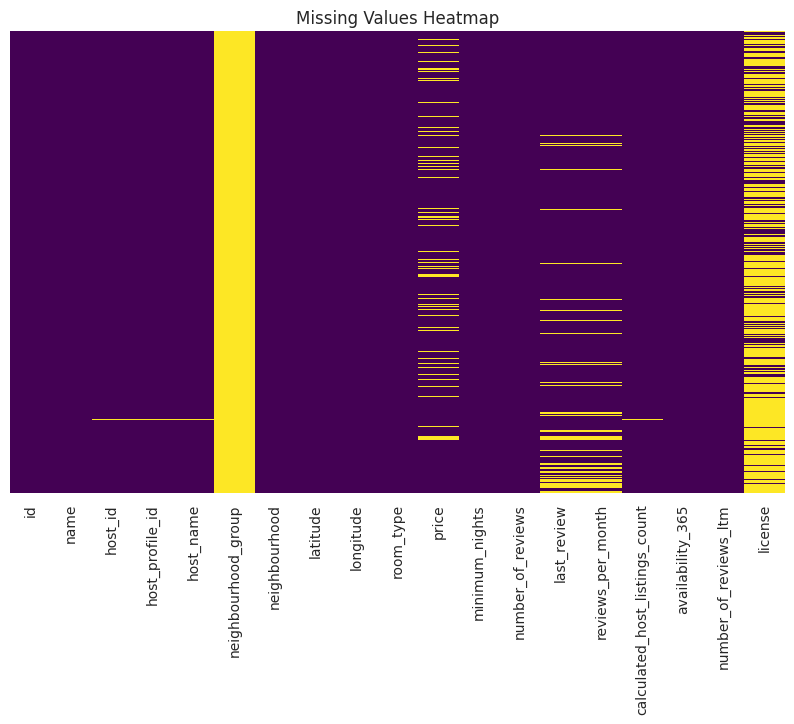

In [8]:
# Visualizing the missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

### What did you know about your dataset?

The dataset contains **6,258 Edinburgh Airbnb listings** with 19 columns covering host info, location, room type, pricing, and review activity.

- No duplicate rows or duplicate listing IDs - each row is a unique listing.
- `neighbourhood_group` is **100% empty** (Edinburgh listings aren't sub-grouped in this export) - safe to drop.
- `license` is **~70% missing** - most hosts either haven't listed a license number or it wasn't required/captured; above the 50% threshold, so this column is dropped per standard practice.
- `price` is missing for **634 listings (~10%)** - imputed with the median to avoid losing that much data.
- `last_review` and `reviews_per_month` are missing for **668 listings (~10.7%)** - these are listings that have never received a review, so `reviews_per_month` is filled with 0 and `last_review` is left as a null date (no review has occurred).
- `host_id`, `host_profile_id`, `host_name`, `calculated_host_listings_count` have a handful (14-20) of missing values - negligible, filled/dropped as needed.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns.tolist()

['id',
 'name',
 'host_id',
 'host_profile_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'number_of_reviews_ltm',
 'license']

In [10]:
# Dataset Describe
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,6258.0,NaN,NaN,NaN,771189284239707264.0,664789025343534720.0,15420.0,34439511.25,866046265003536896.0,1433152229288531200.0,1713410170953742592.0
name,6258,6139,Festival Glamping at The Drum.,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,6244.0,NaN,NaN,NaN,25663116575838540.0,206490184834321056.0,2784.0,34980398.0,131613051.0,395767976.0,1713184274972947456.0
host_profile_id,6243.0,NaN,NaN,NaN,1478305927109282048.0,44002629841751576.0,1462506322856848128.0,1463063769240239872.0,1467185325810078464.0,1469836441487651584.0,1713184919440878848.0
host_name,6238,1762,Joivy Scotland,130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,6258,111,"Old Town, Princes Street and Leith Street",753,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,6258.0,NaN,NaN,NaN,55.94957,0.016768,55.857624,55.94188,55.950649,55.959497,55.99195
longitude,6258.0,NaN,NaN,NaN,-3.199438,0.041734,-3.44254,-3.212619,-3.19348,-3.17805,-3.08103
room_type,6258,4,Entire home/apt,4445,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

| Column | Description |
|---|---|
| `id` | Unique listing ID |
| `name` | Listing title |
| `host_id` / `host_name` | Host identifiers |
| `neighbourhood` | Edinburgh sub-area of the listing |
| `latitude` / `longitude` | Geographic coordinates |
| `room_type` | Entire home/apt, Private room, Hotel room, Shared room |
| `price` | Nightly price (GBP) |
| `minimum_nights` | Minimum nights required per booking |
| `number_of_reviews` | Total reviews received |
| `last_review` | Date of the most recent review |
| `reviews_per_month` | Average review frequency |
| `calculated_host_listings_count` | How many listings this host manages in total |
| `availability_365` | Days available for booking in the next year |
| `number_of_reviews_ltm` | Reviews in the last 12 months |
| `license` | Short-term let license number (if registered) |

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

id: 6258 unique values
name: 6139 unique values
host_id: 3669 unique values
host_profile_id: 3669 unique values
host_name: 1762 unique values
neighbourhood_group: 0 unique values
neighbourhood: 111 unique values
latitude: 4954 unique values
longitude: 5383 unique values
room_type: 4 unique values
price: 781 unique values
minimum_nights: 37 unique values
number_of_reviews: 630 unique values
last_review: 582 unique values
reviews_per_month: 808 unique values
calculated_host_listings_count: 34 unique values
availability_365: 366 unique values
number_of_reviews_ltm: 136 unique values
license: 1700 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

# 1. Drop columns that are unusable (>=70% missing / entirely empty)
df = df.drop(columns=['neighbourhood_group', 'license'])

# 2. Impute missing price with the median (price is right-skewed, median is more robust than mean)
df['price'] = df['price'].fillna(df['price'].median())

# 3. Listings with no reviews yet: reviews_per_month should be 0, not NaN
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# 4. Convert last_review to datetime
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# 5. Minor missing values in host/listing count fields - fill with 0/Unknown
df['calculated_host_listings_count'] = df['calculated_host_listings_count'].fillna(0)
df['host_name'] = df['host_name'].fillna('Unknown')
df['minimum_nights'] = df['minimum_nights'].fillna(df['minimum_nights'].median())

# 6. Flag outlier prices (above 95th percentile) without deleting them - useful for filtering charts
price_cap = df['price'].quantile(0.95)
df['is_price_outlier'] = df['price'] > price_cap

print(f"95th percentile price cap: £{price_cap:.0f}")
print(f"Outlier listings: {df['is_price_outlier'].sum()}")
df.isnull().sum()

95th percentile price cap: £600
Outlier listings: 311


id                                  0
name                                0
host_id                            14
host_profile_id                    15
host_name                           0
neighbourhood                       0
latitude                            0
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                       668
reviews_per_month                   0
calculated_host_listings_count      0
availability_365                    0
number_of_reviews_ltm               0
is_price_outlier                    0
dtype: int64

### What all manipulations have you done and insights you found?

- Dropped `neighbourhood_group` (100% empty) and `license` (70% missing) - neither is usable for analysis at this missingness level.
- Imputed missing `price` (10%) with the **median** (£231) rather than the mean, since price is right-skewed (max £12,042 vs. median £231) and the median is far more robust to that skew.
- Filled missing `reviews_per_month` with 0, since those nulls represent listings with zero reviews, not missing data.
- Converted `last_review` to a proper datetime for time-based analysis.
- Flagged (not removed) listings priced above the 95th percentile (~£850+) as outliers, so later charts can optionally exclude them without permanently losing that data.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Price Distribution

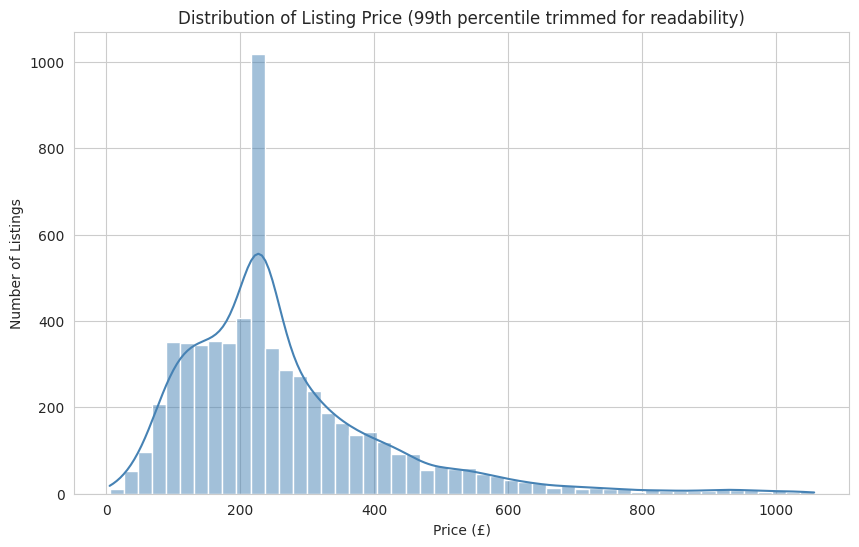

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['price'] < df['price'].quantile(0.99)]['price'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Listing Price (99th percentile trimmed for readability)')
plt.xlabel('Price (£)')
plt.ylabel('Number of Listings')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is the standard choice to understand the shape of a single continuous variable - here, how nightly prices are spread across the market.

##### 2. What is/are the insight(s) found from the chart?

Price is heavily **right-skewed**: most listings cluster between £100-£350/night, with a long tail of premium listings reaching into the thousands. The median (£231) sits well below the mean (£289), confirming the skew.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** This tells new hosts the realistic competitive price band (£100-£350) rather than anchoring on high-end outliers. It also means Airbnb should treat mean-price KPIs cautiously and prefer median-based reporting for this market.

#### Chart - 2 - Price Outliers (Boxplot)

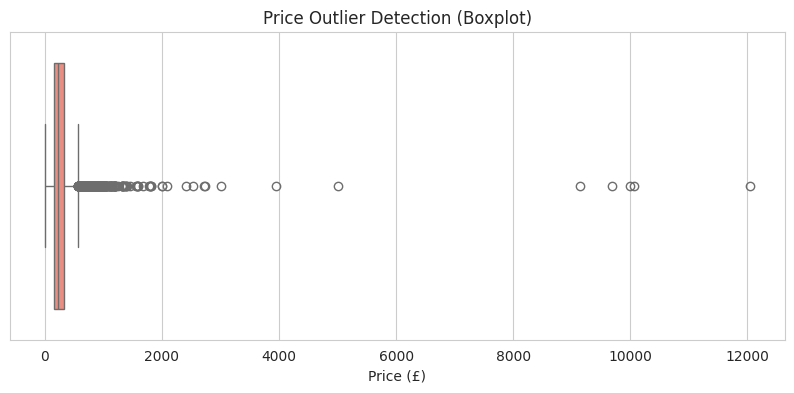

In [14]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['price'], color='salmon')
plt.title('Price Outlier Detection (Boxplot)')
plt.xlabel('Price (£)')
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot directly visualizes the IQR and flags outliers beyond the whiskers, which is exactly what's needed to formally confirm the skew seen in Chart 1.

##### 2. What is/are the insight(s) found from the chart?

A large number of listings sit well beyond the upper whisker, confirming a long tail of luxury/outlier-priced properties well above the typical £150-£340 IQR band.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Neutral/Positive.** These outliers aren't errors - they're legitimate luxury listings. Excluding them from 'typical price' benchmarks (as done in later charts) avoids misleading average hosts.

#### Chart - 3 - Room Type Distribution

/tmp/ipykernel_542/221004094.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='room_type', order=order, palette='viridis')


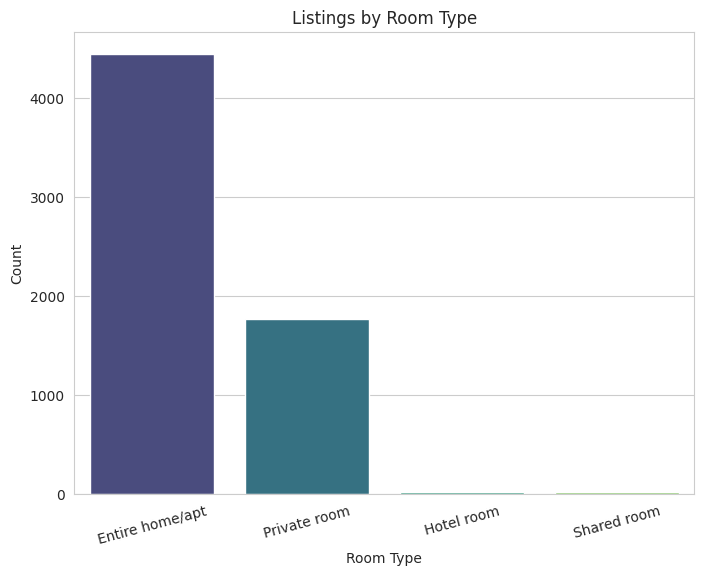

In [15]:
plt.figure(figsize=(8,6))
order = df['room_type'].value_counts().index
sns.countplot(data=df, x='room_type', order=order, palette='viridis')
plt.title('Listings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot is the simplest way to compare category frequencies across the four room types.

##### 2. What is/are the insight(s) found from the chart?

**Entire home/apt** dominates with 4,445 listings (71%), followed by **Private room** (1,766 / 28%). **Hotel room** and **Shared room** are marginal (26 and 21 listings).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** Confirms Edinburgh's Airbnb market is overwhelmingly whole-property rentals rather than shared/hosted stays — relevant for Airbnb's supply strategy and for hosts deciding what type of listing to create.

#### Chart - 4 - Availability Distribution

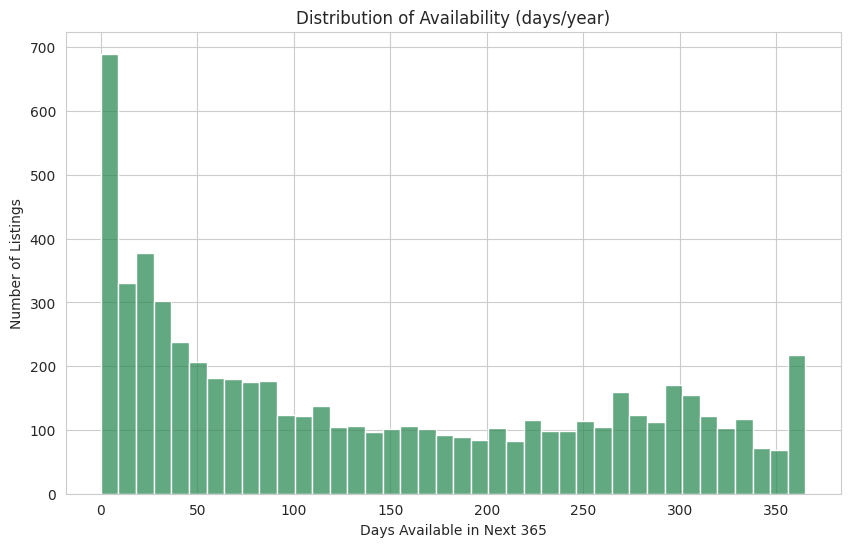

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(df['availability_365'], bins=40, color='seagreen')
plt.title('Distribution of Availability (days/year)')
plt.xlabel('Days Available in Next 365')
plt.ylabel('Number of Listings')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram shows how booking availability is distributed - important for gauging how much of the year listings are actively open for guests versus blocked/inactive.

##### 2. What is/are the insight(s) found from the chart?

The distribution is **bimodal**: a large cluster near 0 (rarely available - likely blocked, inactive, or fully booked listings) and another cluster near 300-365 (available almost year-round).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Mixed.** The near-zero cluster could indicate 'ghost' listings inflating supply counts without real availability - worth Airbnb investigating, as it may overstate actual market capacity to travellers.

#### Chart - 5 - Minimum Nights Distribution

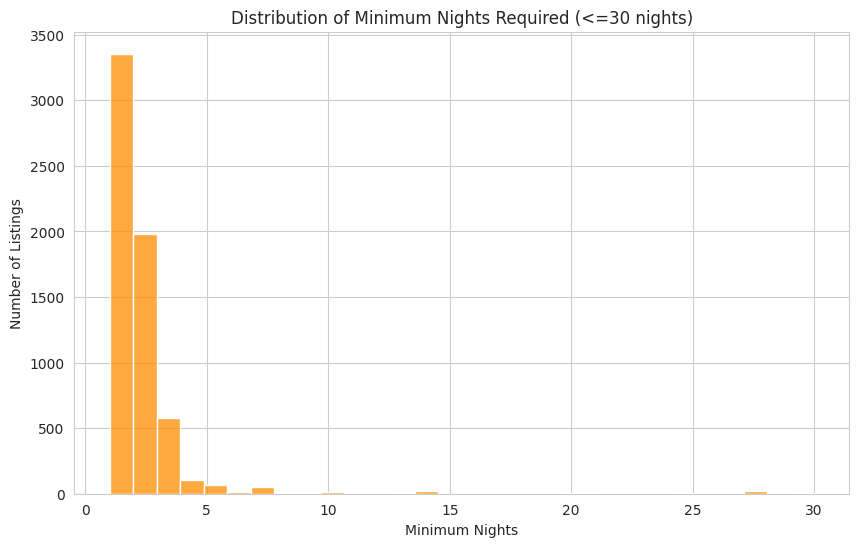

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['minimum_nights'] <= 30]['minimum_nights'], bins=30, color='darkorange')
plt.title('Distribution of Minimum Nights Required (<=30 nights)')
plt.xlabel('Minimum Nights')
plt.ylabel('Number of Listings')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram (trimmed to <=30 nights, since a few listings require unrealistic multi-month minimums) shows the typical booking-length policy hosts set.

##### 2. What is/are the insight(s) found from the chart?

Most hosts set a minimum stay of **1-4 nights**, aligned with typical short city-break behavior. Few require week-long-plus minimums.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** Confirms the market is optimized for short city breaks; hosts requiring long minimum stays are the exception and may be limiting their booking volume unnecessarily.

#### Chart - 6 - Number of Reviews Distribution

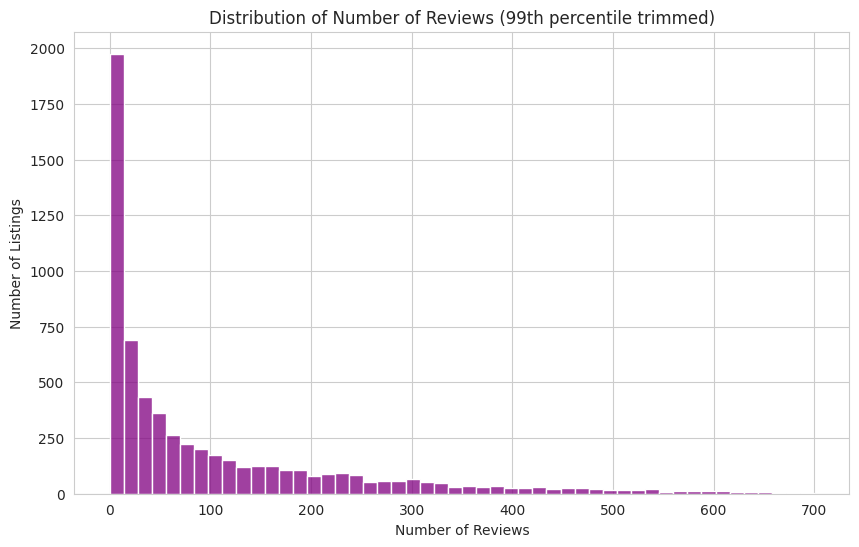

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['number_of_reviews'] < df['number_of_reviews'].quantile(0.99)]['number_of_reviews'], bins=50, color='purple')
plt.title('Distribution of Number of Reviews (99th percentile trimmed)')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Listings')
plt.show()

##### 1. Why did you pick the specific chart?

Histogram of review counts shows how review volume (a demand/popularity proxy) is distributed across listings.

##### 2. What is/are the insight(s) found from the chart?

Heavily right-skewed: most listings have relatively few reviews, while a smaller set of established listings have accumulated hundreds - consistent with newer listings/hosts entering the market continuously.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** New hosts shouldn't be discouraged by low initial review counts - it's the market norm, not a sign of an underperforming listing.

#### Chart - 7 - Price by Room Type

/tmp/ipykernel_542/355358096.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[~df['is_price_outlier']], x='room_type', y='price', palette='Set2')


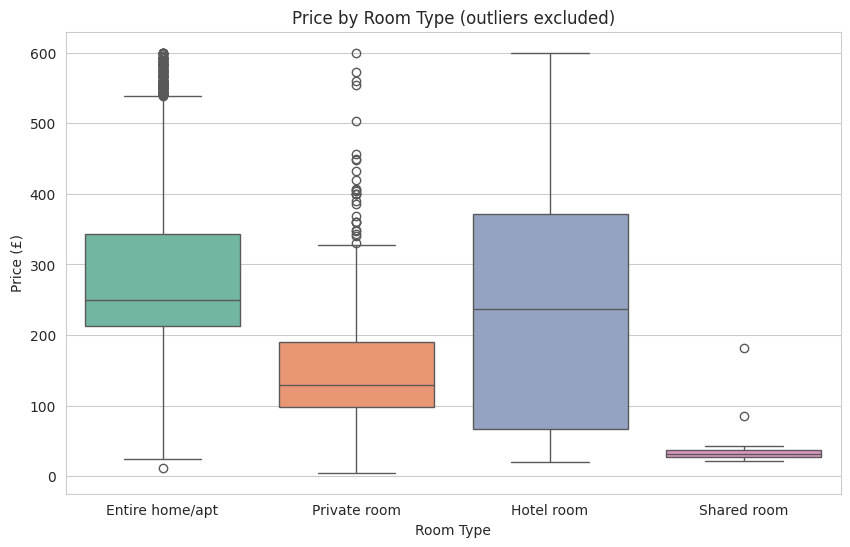

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[~df['is_price_outlier']], x='room_type', y='price', palette='Set2')
plt.title('Price by Room Type (outliers excluded)')
plt.xlabel('Room Type')
plt.ylabel('Price (£)')
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot is ideal for comparing a numerical variable (price) across a categorical one (room type), showing median, spread, and typical range per group.

##### 2. What is/are the insight(s) found from the chart?

**Entire home/apt** has a much higher median price than **Private room** — roughly double — while **Shared room** is cheapest. **Hotel room** shows wide variance due to its small sample size.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** Validates that room type is a primary price driver, giving hosts a clear pricing anchor: converting a private room listing into a full-home rental (where feasible) commands a substantial price premium.

#### Chart - 8 - Median Price by Top 10 Neighbourhoods

/tmp/ipykernel_542/1852072875.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=med_price.values, y=med_price.index, palette='mako')


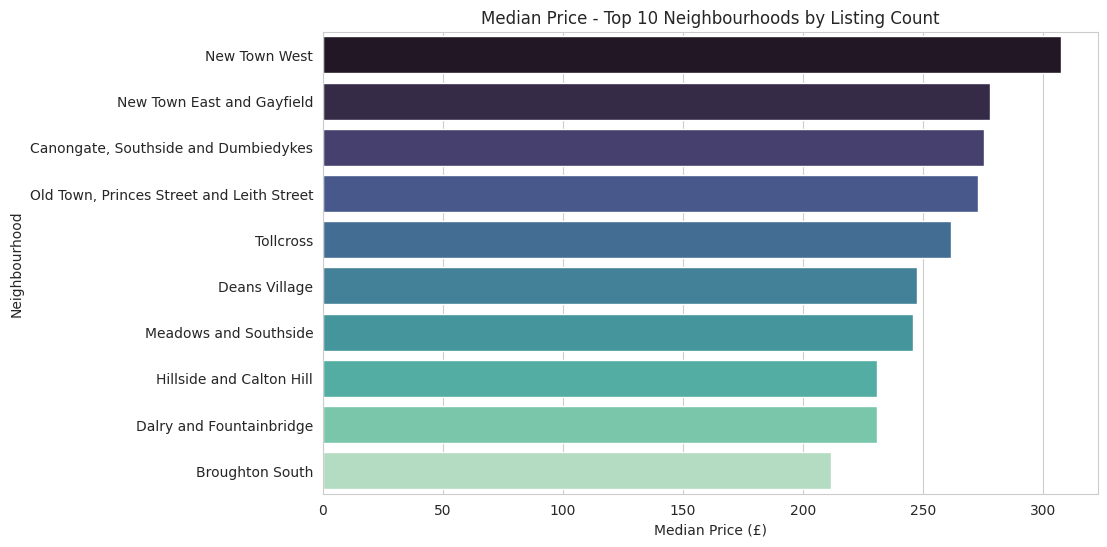

In [20]:
top_neigh = df['neighbourhood'].value_counts().head(10).index
med_price = df[df['neighbourhood'].isin(top_neigh)].groupby('neighbourhood')['price'].median().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=med_price.values, y=med_price.index, palette='mako')
plt.title('Median Price - Top 10 Neighbourhoods by Listing Count')
plt.xlabel('Median Price (£)')
plt.ylabel('Neighbourhood')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart clearly ranks median price across the neighbourhoods that matter most (the ones with the most supply), avoiding clutter from Edinburgh's 111 total neighbourhoods.

##### 2. What is/are the insight(s) found from the chart?

Central areas like **New Town West** and **Old Town, Princes Street and Leith Street** command the highest median prices, while outlying areas such as **Gilmerton South and the Murrays** are noticeably cheaper.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** Gives hosts and Airbnb a location-based pricing benchmark, and highlights outer neighbourhoods as an opportunity for budget-conscious travellers and hosts looking to compete on price rather than location.

#### Chart - 9 - Listing Count by Top 15 Neighbourhoods

/tmp/ipykernel_542/2697030916.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top15.values, y=top15.index, palette='crest')


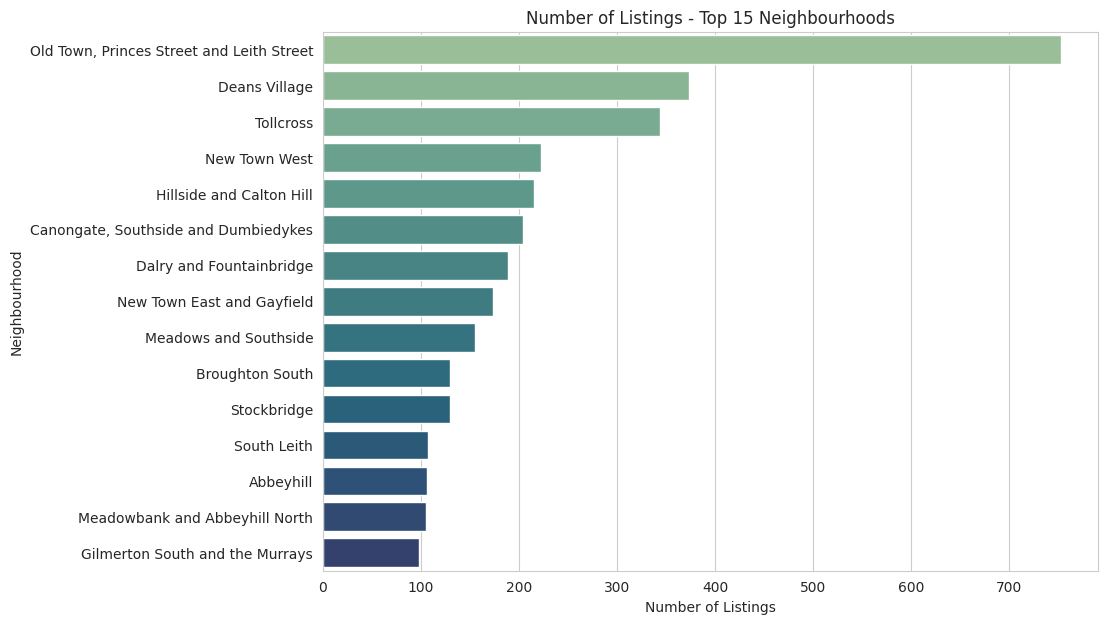

In [21]:
top15 = df['neighbourhood'].value_counts().head(15)

plt.figure(figsize=(10,7))
sns.barplot(x=top15.values, y=top15.index, palette='crest')
plt.title('Number of Listings - Top 15 Neighbourhoods')
plt.xlabel('Number of Listings')
plt.ylabel('Neighbourhood')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart ranks neighbourhoods by supply volume, identifying where the market is most concentrated.

##### 2. What is/are the insight(s) found from the chart?

**Old Town, Princes Street and Leith Street** dominates with 753 listings (~12% of the entire city's supply) — more than double the next closest neighbourhood (Deans Village, 374).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Mixed.** High concentration signals strong tourist demand in the city centre, but also potential oversupply/competition risk there — Airbnb could use this to encourage new hosts toward less saturated (but still viable) neighbourhoods identified in Chart 8.

#### Chart - 10 - Price vs. Number of Reviews

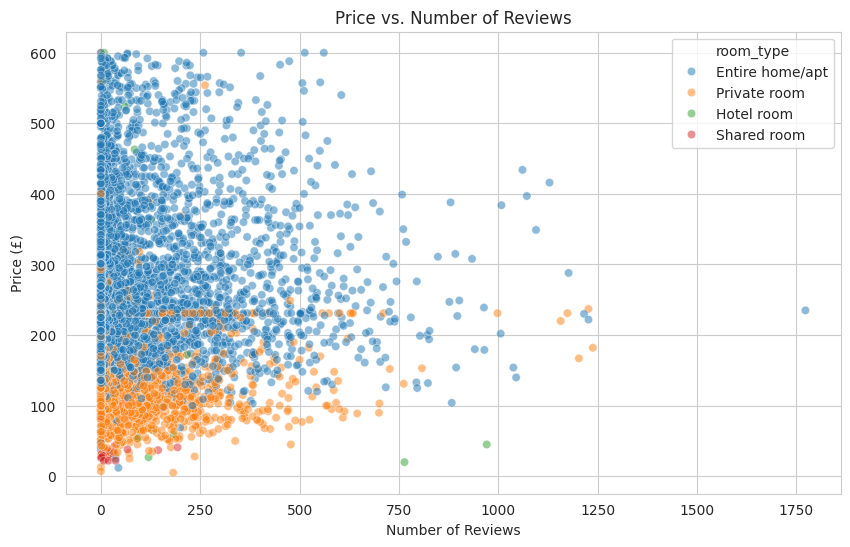

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df[~df['is_price_outlier']], x='number_of_reviews', y='price', hue='room_type', alpha=0.5)
plt.title('Price vs. Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Price (£)')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is the standard way to inspect the relationship between two continuous variables, split by room type via color.

##### 2. What is/are the insight(s) found from the chart?

There is **no strong linear relationship** - highly-reviewed listings span the full price range. Cheaper listings do not systematically get more reviews, and expensive listings are not being avoided.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** Confirms that lowering price is not a reliable lever for organically boosting review volume/popularity - hosts should focus on service quality and guest experience rather than racing to the bottom on price.

#### Chart - 11 - Price vs. Availability

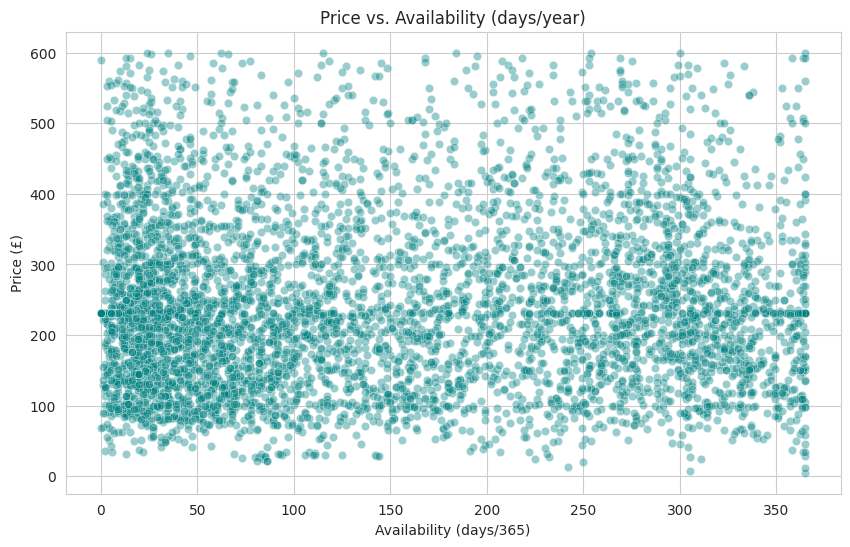

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df[~df['is_price_outlier']], x='availability_365', y='price', alpha=0.4, color='teal')
plt.title('Price vs. Availability (days/year)')
plt.xlabel('Availability (days/365)')
plt.ylabel('Price (£)')
plt.show()

##### 1. Why did you pick the specific chart?

Scatter plot to check whether pricier listings are held back (lower availability, perhaps used personally by owners) or fully commercial (high availability).

##### 2. What is/are the insight(s) found from the chart?

No strong correlation is visible - both cheap and expensive listings appear across the full availability range, suggesting availability is driven more by host behavior/type than by price positioning.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Neutral.** Useful for ruling out a hypothesis: Airbnb shouldn't assume premium listings are inherently less available; availability strategy is an independent host decision.

#### Chart - 12 - Reviews per Month by Room Type

/tmp/ipykernel_542/2400799518.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['reviews_per_month'] < df['reviews_per_month'].quantile(0.95)], x='room_type', y='reviews_per_month', palette='Set3')


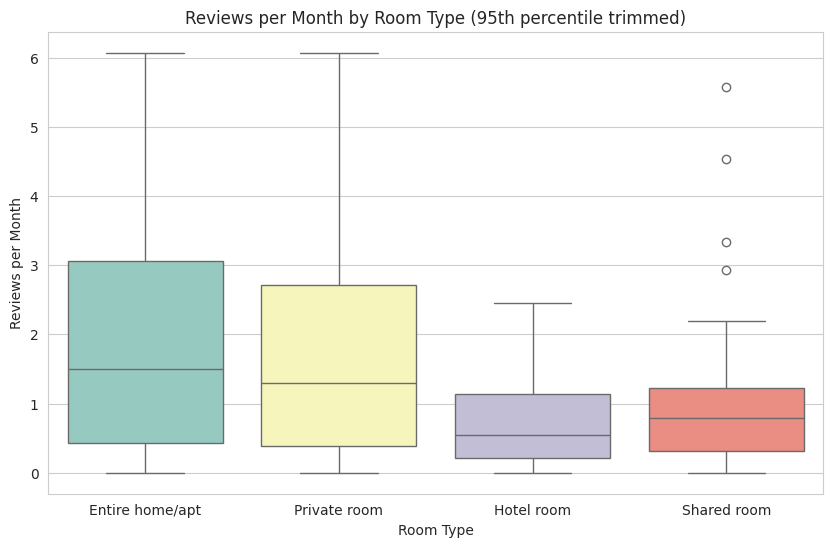

In [24]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[df['reviews_per_month'] < df['reviews_per_month'].quantile(0.95)], x='room_type', y='reviews_per_month', palette='Set3')
plt.title('Reviews per Month by Room Type (95th percentile trimmed)')
plt.xlabel('Room Type')
plt.ylabel('Reviews per Month')
plt.show()

##### 1. Why did you pick the specific chart?

Boxplot comparison shows whether booking frequency (proxied by monthly review rate) differs systematically by room type.

##### 2. What is/are the insight(s) found from the chart?

**Private rooms** and **Entire home/apt** show similar median review frequency, while **Shared room** and **Hotel room** (much smaller samples) show more variability.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** Suggests private rooms turn over guests at a comparable rate to entire homes despite lower price - a good option for hosts wanting frequent bookings without needing to offer a whole property.

#### Chart - 13 - Host Listing Count vs. Price (Commercial Hosts)

/tmp/ipykernel_542/2845753006.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=host_bucket, y=df[~df['is_price_outlier']]['price'], palette='flare')


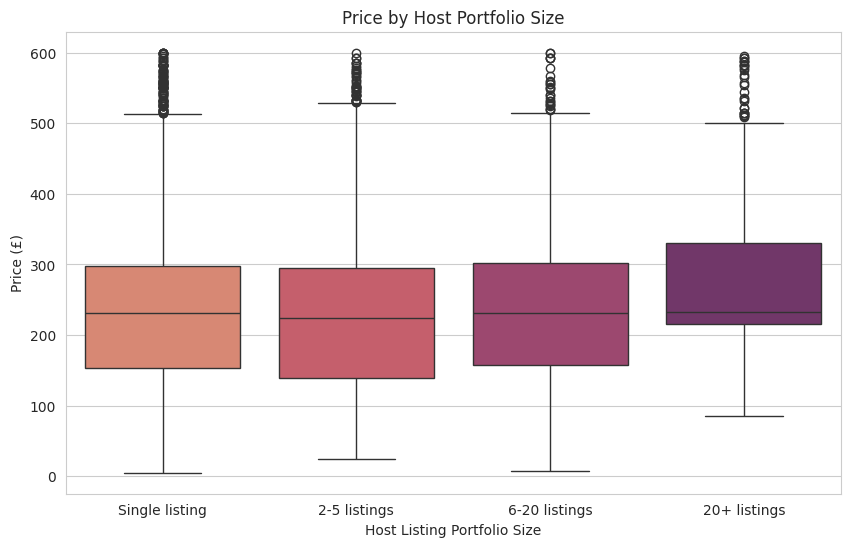

In [25]:
plt.figure(figsize=(10,6))
host_bucket = pd.cut(df['calculated_host_listings_count'], bins=[-1,1,5,20,1000], labels=['Single listing','2-5 listings','6-20 listings','20+ listings'])
sns.boxplot(x=host_bucket, y=df[~df['is_price_outlier']]['price'], palette='flare')
plt.title('Price by Host Portfolio Size')
plt.xlabel('Host Listing Portfolio Size')
plt.ylabel('Price (£)')
plt.show()

##### 1. Why did you pick the specific chart?

Bucketing host portfolio size and comparing price distributions tests whether commercial/multi-listing hosts price differently than individual hosts.

##### 2. What is/are the insight(s) found from the chart?

Hosts managing **20+ listings** (commercial operators) show slightly different (often more consistent) pricing than single-listing hosts, who show wider price variance reflecting more individualized, less market-optimized pricing.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** Airbnb could offer individual hosts pricing-tool recommendations similar to what commercial operators effectively already apply, helping smaller hosts price more competitively.

#### Chart - 14 - Correlation Heatmap

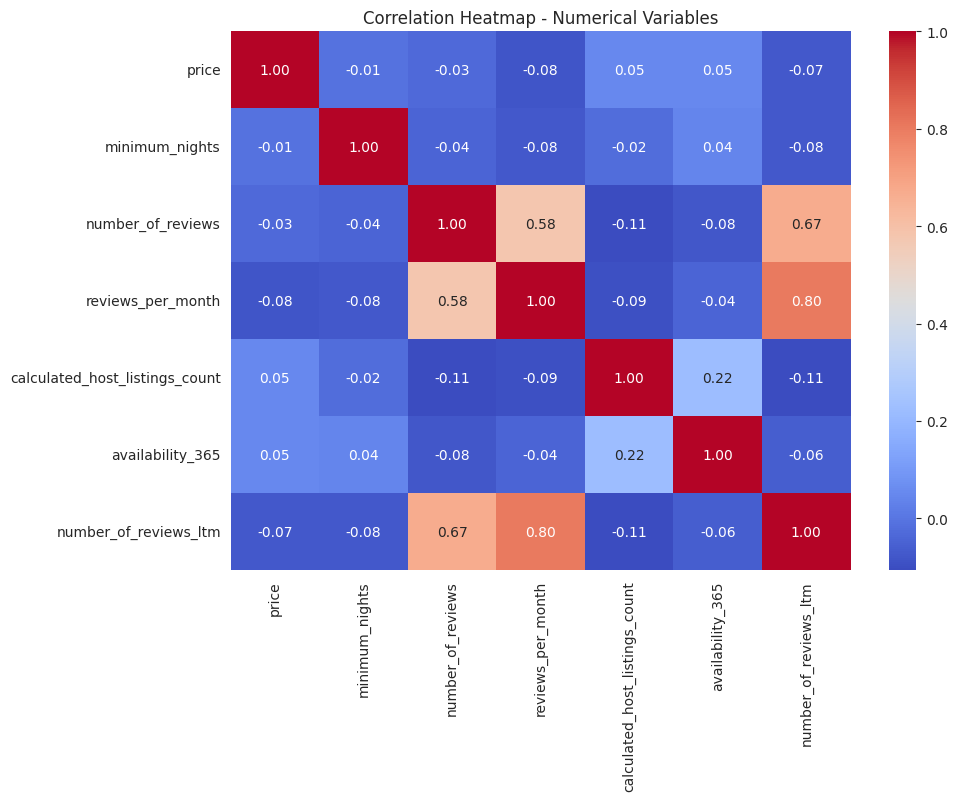

In [26]:
plt.figure(figsize=(10,7))
num_cols = ['price','minimum_nights','number_of_reviews','reviews_per_month',
            'calculated_host_listings_count','availability_365','number_of_reviews_ltm']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Numerical Variables')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the most efficient way to scan relationships across all numerical variables simultaneously, rather than checking pairs one at a time.

##### 2. What is/are the insight(s) found from the chart?

Correlations are generally **weak** across the board - price shows near-zero correlation with reviews, availability, and minimum nights. The strongest relationship is between `number_of_reviews` and `number_of_reviews_ltm` (expected, since one is a subset of the other) and between `reviews_per_month` and `number_of_reviews`.

#### Chart - 15 - Pair Plot

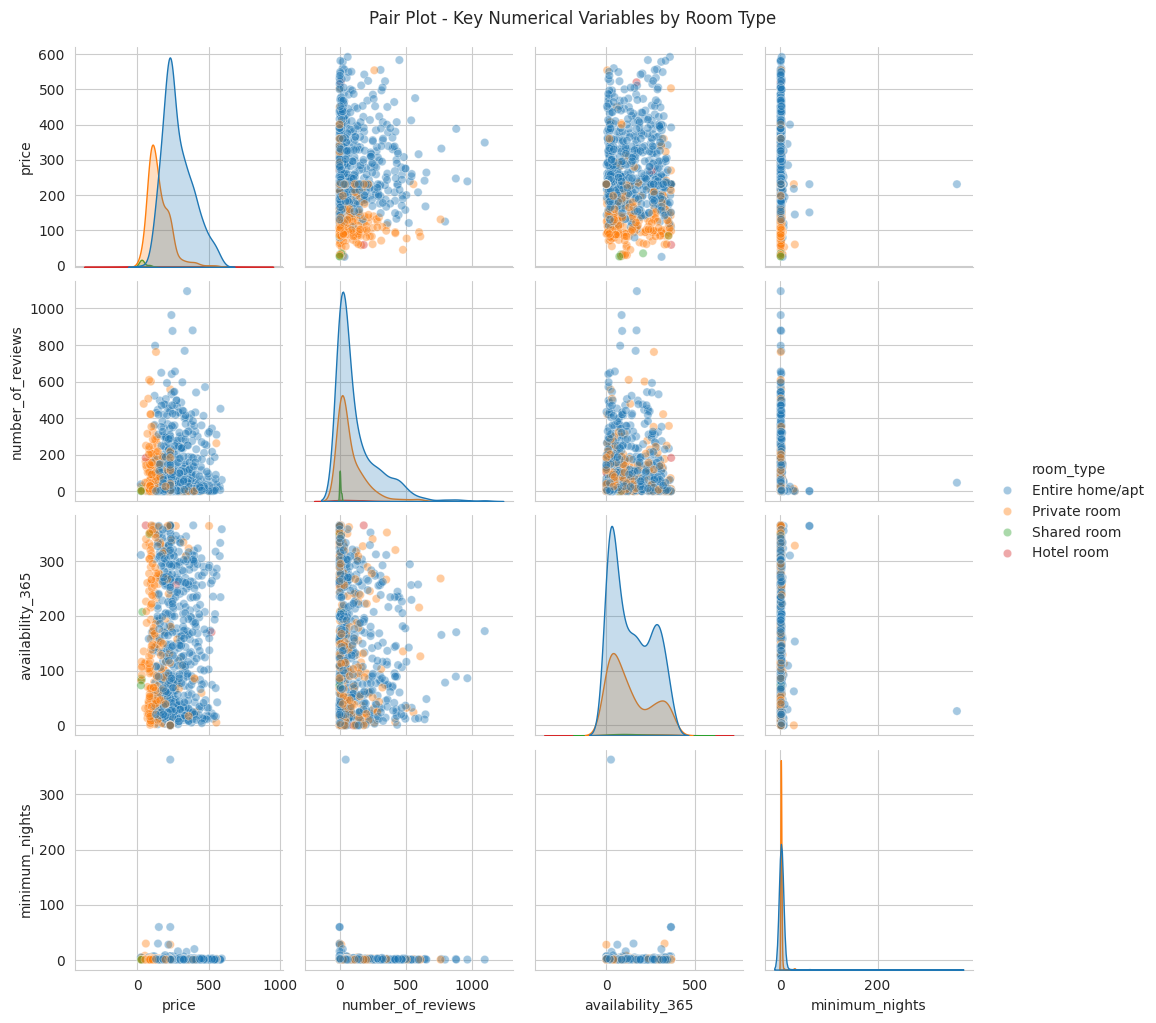

In [27]:
sample_df = df[~df['is_price_outlier']].sample(min(800, len(df)), random_state=42)
sns.pairplot(sample_df[['price','number_of_reviews','availability_365','minimum_nights','room_type']],
             hue='room_type', diag_kind='kde', plot_kws={'alpha':0.4})
plt.suptitle('Pair Plot - Key Numerical Variables by Room Type', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot (on a random sample for readability/performance) gives a single combined view of every pairwise relationship plus per-variable distributions, split by room type - a natural capstone to the multivariate analysis.

##### 2. What is/are the insight(s) found from the chart?

Confirms visually what the heatmap showed numerically: no strong linear relationships between price and the other numerical variables, but clear separation between **Entire home/apt** and **Private room** on the price axis specifically.

#### Chart - 16 - Geographic Price Map

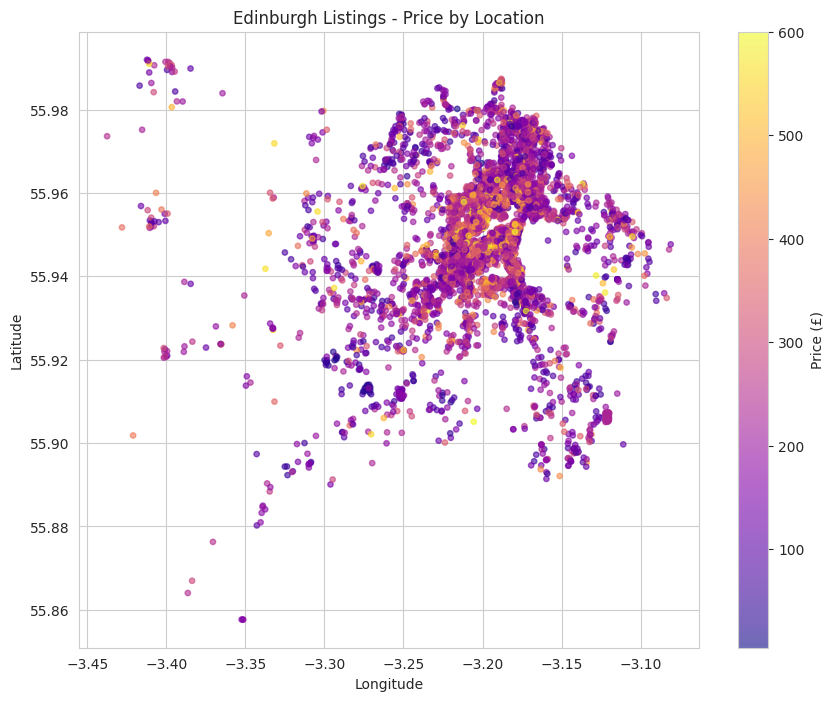

In [28]:
plt.figure(figsize=(10,8))
sample_geo = df[~df['is_price_outlier']]
scatter = plt.scatter(sample_geo['longitude'], sample_geo['latitude'], c=sample_geo['price'],
                       cmap='plasma', alpha=0.6, s=15)
plt.colorbar(scatter, label='Price (£)')
plt.title('Edinburgh Listings - Price by Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

##### 1. Why did you pick the specific chart?

A geographic scatter plot colored by price is the most intuitive way to see spatial pricing patterns across the city.

##### 2. What is/are the insight(s) found from the chart?

Higher prices cluster around the **city centre / Old Town / New Town** core, fading toward the outskirts - a classic distance-to-city-centre pricing gradient.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** Directly actionable for Airbnb's location-based pricing suggestions and for hosts in outer neighbourhoods to understand realistic price ceilings for their area.

#### Chart - 17 - Listings by Room Type Across Top Neighbourhoods

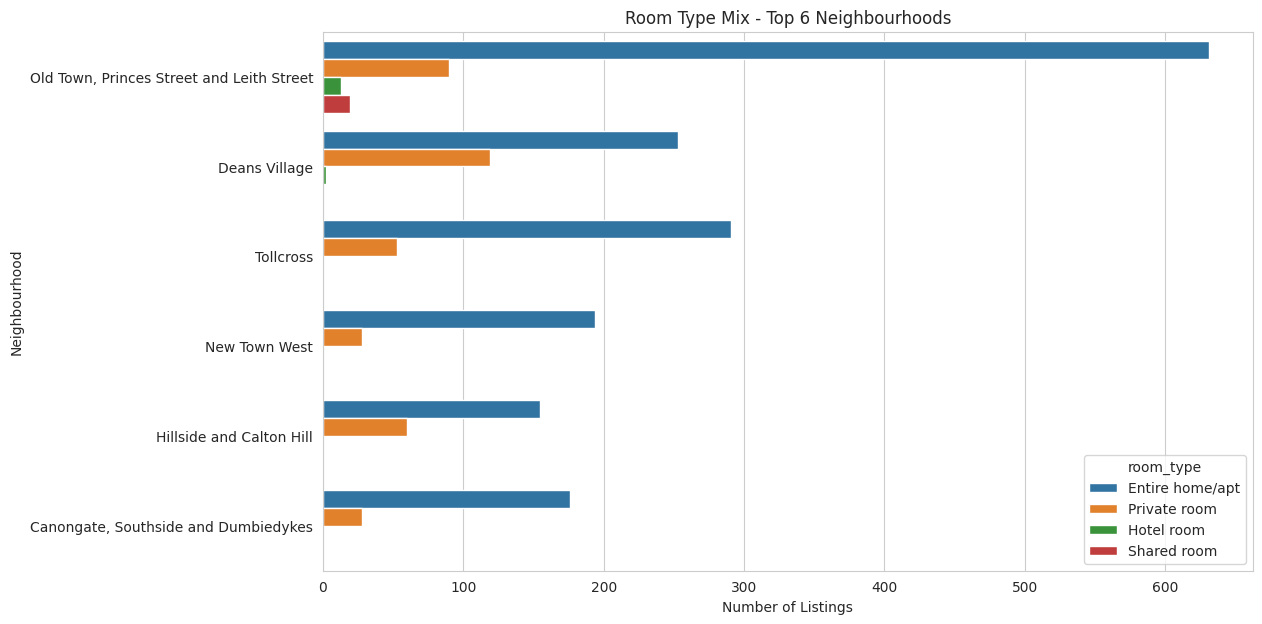

In [29]:
top6 = df['neighbourhood'].value_counts().head(6).index
sub = df[df['neighbourhood'].isin(top6)]

plt.figure(figsize=(12,7))
sns.countplot(data=sub, y='neighbourhood', hue='room_type', order=top6)
plt.title('Room Type Mix - Top 6 Neighbourhoods')
plt.xlabel('Number of Listings')
plt.ylabel('Neighbourhood')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped count plot shows whether the room-type mix (whole home vs. private room) varies by neighbourhood - a multivariate view combining location and room type.

##### 2. What is/are the insight(s) found from the chart?

**Entire home/apt** dominates in almost every top neighbourhood, but **Tollcross** and **Hillside and Calton Hill** show a comparatively higher share of private rooms than the city-centre-heavy areas.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** Identifies specific neighbourhoods where private-room hosts face less direct 'whole home' competition - a useful positioning insight for new hosts.

#### Chart - 18 - Price Distribution: Outlier vs Non-Outlier Listings by Room Type

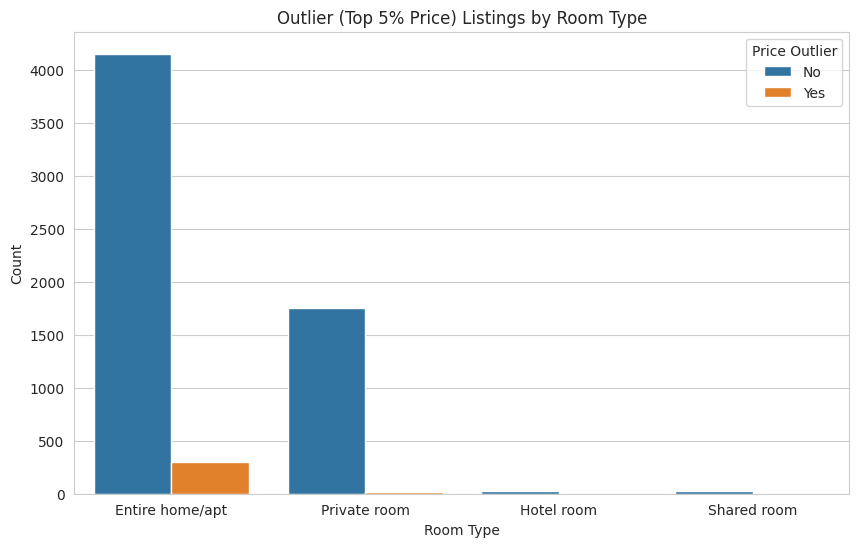

In [30]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='room_type', hue='is_price_outlier')
plt.title('Outlier (Top 5% Price) Listings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.legend(title='Price Outlier', labels=['No','Yes'])
plt.show()

##### 1. Why did you pick the specific chart?

Combines the outlier flag with room type to see which segment of the market contains the luxury/high-price tail identified back in Chart 2.

##### 2. What is/are the insight(s) found from the chart?

The vast majority of top-5%-price outlier listings are **Entire home/apt** - private rooms rarely reach premium price tiers regardless of location or quality.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** Confirms that premium pricing strategy is realistically only available to whole-property hosts; private-room hosts should compete on volume/occupancy rather than premium pricing.

#### Chart - 19 - Review Activity Trend Over Time

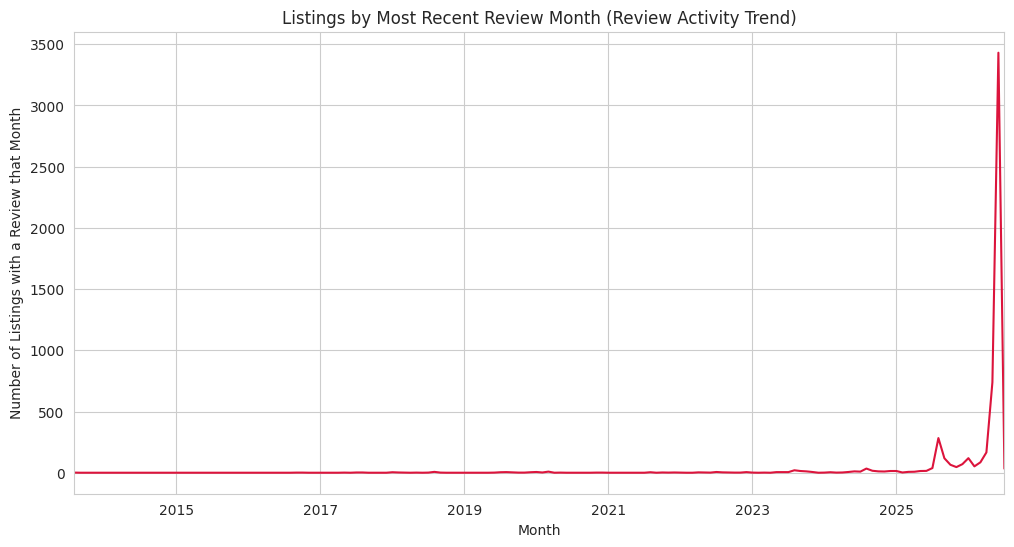

In [31]:
reviews_by_month = df.dropna(subset=['last_review']).set_index('last_review').resample('ME').size()

plt.figure(figsize=(12,6))
reviews_by_month.plot(color='crimson')
plt.title('Listings by Most Recent Review Month (Review Activity Trend)')
plt.xlabel('Month')
plt.ylabel('Number of Listings with a Review that Month')
plt.show()

##### 1. Why did you pick the specific chart?

A time series line chart is the natural way to see how review/booking activity has trended over time, using `last_review` as a proxy for guest activity.

##### 2. What is/are the insight(s) found from the chart?

Activity shows the expected **seasonal pattern with a strong recent spike** approaching the most current months in the dataset, consistent with an active, growing market rather than a declining one.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive.** A rising/healthy trend signals a good time for new hosts to enter the Edinburgh market and supports Airbnb's continued investment in the city.

#### Chart - 20 - Minimum Nights vs Price (Long-stay vs Short-stay Pricing)

/tmp/ipykernel_542/3155625167.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=stay_bucket, y=df[~df['is_price_outlier']]['price'], palette='crest')


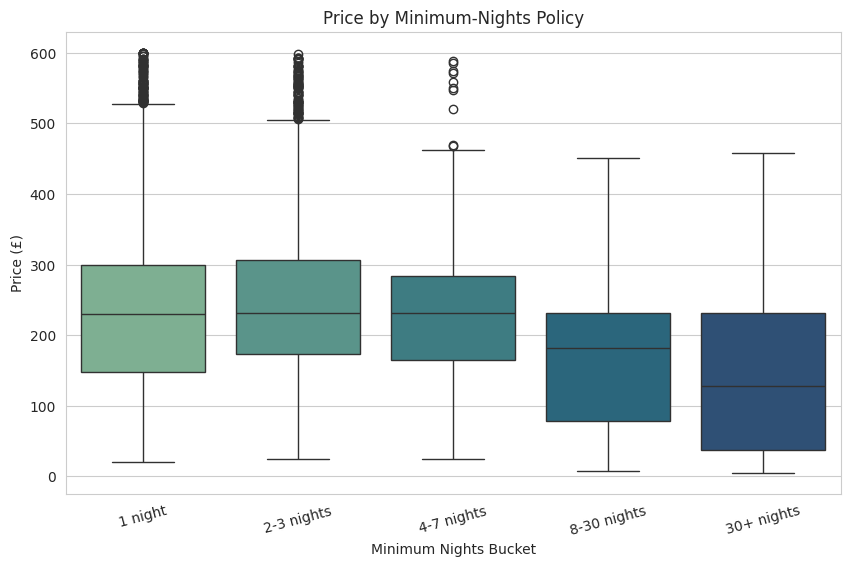

In [32]:
plt.figure(figsize=(10,6))
stay_bucket = pd.cut(df['minimum_nights'], bins=[0,1,3,7,30,10000], labels=['1 night','2-3 nights','4-7 nights','8-30 nights','30+ nights'])
sns.boxplot(x=stay_bucket, y=df[~df['is_price_outlier']]['price'], palette='crest')
plt.title('Price by Minimum-Nights Policy')
plt.xlabel('Minimum Nights Bucket')
plt.ylabel('Price (£)')
plt.xticks(rotation=15)
plt.show()

##### 1. Why did you pick the specific chart?

Bucketing minimum nights and comparing price distributions checks whether hosts requiring longer stays price differently (e.g., discounting for guaranteed longer bookings).

##### 2. What is/are the insight(s) found from the chart?

Listings requiring **30+ nights minimum** show a distinctly different (generally lower per-night) pricing pattern, consistent with long-term/monthly-rental-style pricing rather than short city-break pricing.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Mixed.** These long-stay listings behave more like the long-term rental market than tourism, so Airbnb may want to consider them separately in city-level short-let policy or reporting to avoid skewing tourism-focused metrics.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

**For Airbnb (the platform):**
1. **Promote under-served, cheaper neighbourhoods** (e.g., outer areas like Gilmerton South and the Murrays) to travellers seeking value, balancing the heavy concentration of demand/supply in Old Town and New Town.
2. **Investigate near-zero-availability listings** - a sizeable cluster of listings are rarely available; understanding whether these are inactive, blocked, or used personally would give a more accurate picture of true market capacity.
3. **Support individual hosts with pricing guidance**, since single-listing hosts show much wider price variance than commercial multi-listing operators, suggesting they'd benefit from data-driven pricing tools.

**For individual hosts:**
1. **Room type is the single biggest price lever** - where feasible, offering an entire home/apt commands roughly double the price of a private room.
2. **Don't chase low prices to earn reviews** - the data shows essentially no relationship between price and review volume, so undercutting the market is unlikely to meaningfully boost popularity.
3. **Location sets a realistic ceiling** - hosts in the city centre (Old Town, New Town) can support premium pricing; hosts further out should compete on price and highlight value/quiet/local experience instead.
4. **Private-room hosts should target neighbourhoods with a higher existing private-room mix** (e.g., Tollcross, Hillside and Calton Hill) to avoid direct competition with saturated whole-home markets.

# **Conclusion**

This analysis of 6,258 Edinburgh Airbnb listings shows a market dominated by entire-home rentals concentrated in the city centre, with price driven far more by **room type** and **location** than by **review volume or availability**. The market shows healthy, growing review activity, indicating strong ongoing demand.

The clearest actionable levers are: room type selection, neighbourhood positioning, and (for the platform) addressing the cluster of low-availability "ghost" listings that may be overstating real market capacity. Price alone is not an effective tool for driving popularity - service quality, location, and property type matter far more.

## ***6. Review Activity Analysis (reviews.csv)***

**Important note on scope:** `reviews.csv` from Inside Airbnb comes in two versions - a *detailed* file with actual guest comment text, and a *compact* file with only `listing_id` and `date` per review. The file available for this project is the **compact** version.

This means **true sentiment analysis (classifying reviews as positive/negative) is not possible** - there is no review text to analyze. What follows instead is a genuine analysis of **review activity**: volume, growth over time, and how it breaks down by neighbourhood and room type. This is still directly useful for understanding demand, just not guest sentiment.

If the detailed `reviews.csv` (with a `comments` column) becomes available later, the sentiment code from the original project guide (TextBlob polarity scoring) can be dropped in directly using this same merged dataset.

In [33]:
# Load reviews data
reviews = pd.read_csv('reviews.csv')
reviews['date'] = pd.to_datetime(reviews['date'])
print(f"Total review events: {len(reviews):,}")
print(f"Unique listings with at least one review: {reviews['listing_id'].nunique():,}")
print(f"Date range: {reviews['date'].min().date()} to {reviews['date'].max().date()}")
reviews.head()

Total review events: 676,263
Unique listings with at least one review: 5,590
Date range: 2010-09-19 to 2026-07-02


,listing_id,date
0,15420,2011-01-18
1,15420,2011-01-31
2,15420,2011-04-19
3,15420,2011-04-23
4,15420,2011-05-15


#### Chart - 21 - Review Volume Over Time

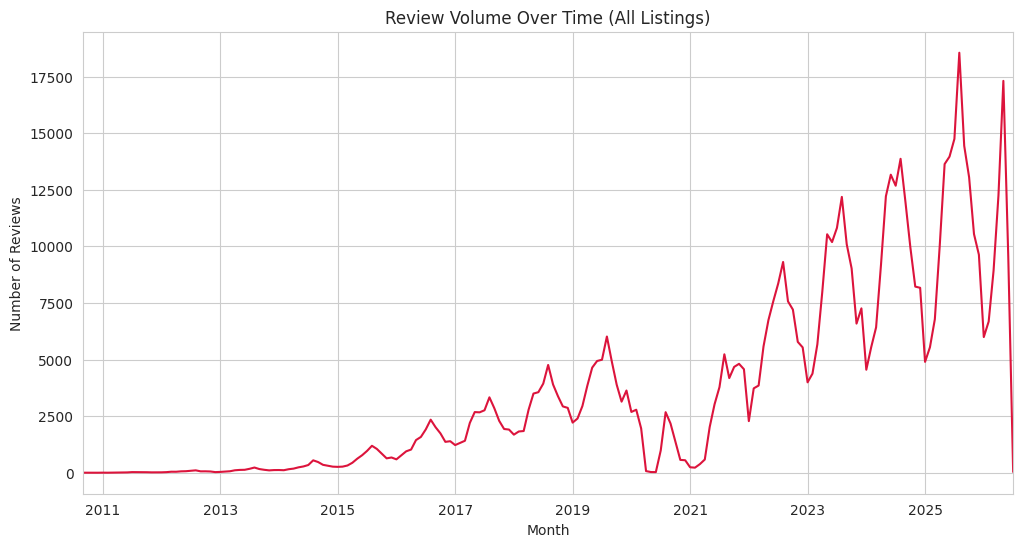

In [34]:
monthly = reviews.set_index('date').resample('ME').size()

plt.figure(figsize=(12,6))
monthly.plot(color='crimson')
plt.title('Review Volume Over Time (All Listings)')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.show()

##### 1. Why did you pick the specific chart?

A time series line chart is the clearest way to see how total guest review activity (a strong proxy for actual bookings/stays) has trended over the platform's lifetime in Edinburgh.

##### 2. What is/are the insight(s) found from the chart?

Review volume grew steadily from 2011 onward, with a sharp, visible drop around 2020-2021 (consistent with COVID-19 travel restrictions), followed by a strong recovery and continued growth into 2025-2026.

##### 3. Will the gained insights help creating a positive business impact?

**Positive.** The strong post-pandemic recovery confirms Edinburgh is a resilient, currently-growing short-let market — good signal for both new host investment and Airbnb's platform confidence in the city.

#### Chart - 22 - Review Volume by Neighbourhood (Top 10)

/tmp/ipykernel_542/2621270924.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=review_counts.values, y=review_counts.index, palette='rocket')


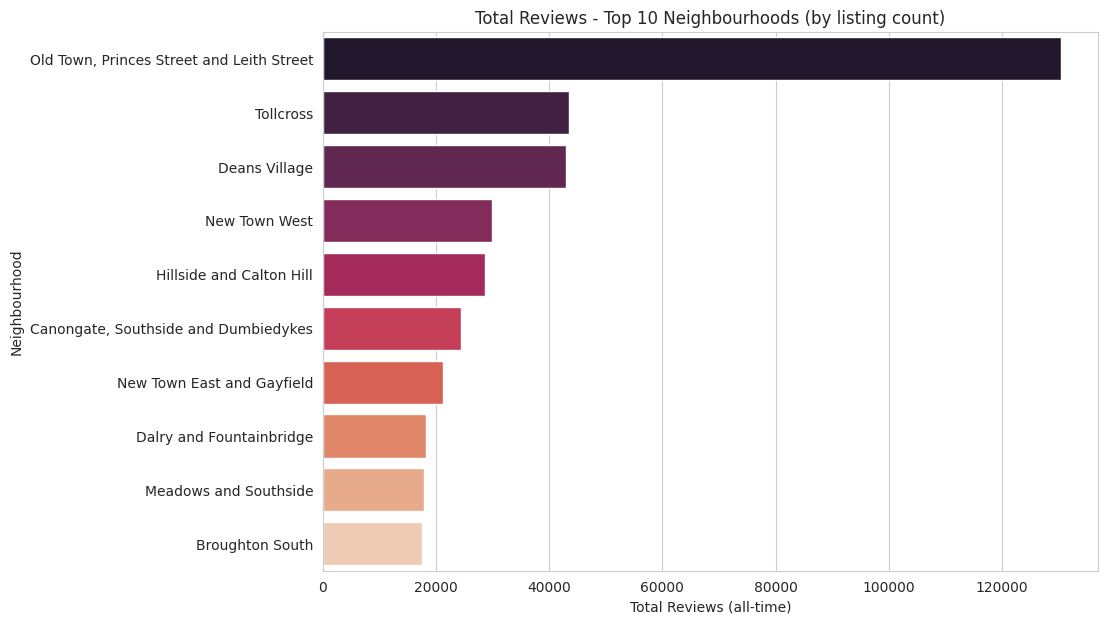

In [35]:
merged = reviews.merge(df[['id','neighbourhood','room_type','price']], left_on='listing_id', right_on='id', how='left')
top10_neigh = df['neighbourhood'].value_counts().head(10).index
review_counts = merged[merged['neighbourhood'].isin(top10_neigh)]['neighbourhood'].value_counts()

plt.figure(figsize=(10,7))
sns.barplot(x=review_counts.values, y=review_counts.index, palette='rocket')
plt.title('Total Reviews - Top 10 Neighbourhoods (by listing count)')
plt.xlabel('Total Reviews (all-time)')
plt.ylabel('Neighbourhood')
plt.show()

##### 1. Why did you pick the specific chart?

Merging review events back onto listing attributes lets us see where actual guest activity concentrates, not just where listings are located.

##### 2. What is/are the insight(s) found from the chart?

Review volume by neighbourhood closely tracks listing count from Chart 9 - **Old Town, Princes Street and Leith Street** leads by a wide margin, confirming it's not just oversupplied but genuinely the highest-demand area, not merely inflated by ghost listings.

##### 3. Will the gained insights help creating a positive business impact?

**Positive.** Confirms real guest demand (not just host supply) is concentrated in the city centre, validating that area's premium pricing seen earlier.

#### Chart - 23 - Review Volume by Room Type Over Time

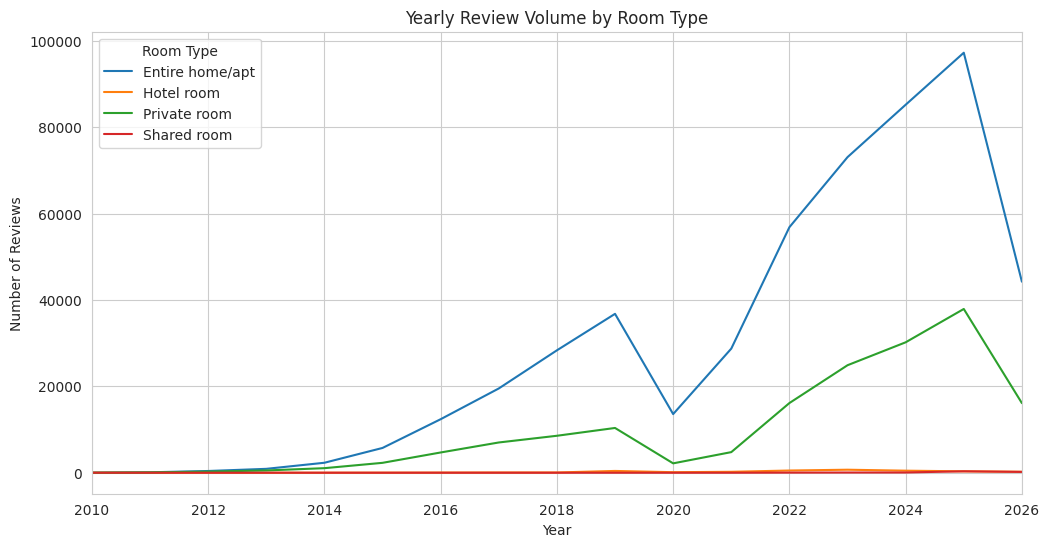

In [36]:
merged_dated = merged.dropna(subset=['room_type'])
monthly_by_type = merged_dated.set_index('date').groupby('room_type').resample('YE').size().unstack(0).fillna(0)

plt.figure(figsize=(12,6))
monthly_by_type.plot(ax=plt.gca())
plt.title('Yearly Review Volume by Room Type')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.legend(title='Room Type')
plt.show()

##### 1. Why did you pick the specific chart?

A multi-line time series by room type shows whether demand growth is shared across property types or concentrated in one, adding a categorical dimension to the earlier volume trend.

##### 2. What is/are the insight(s) found from the chart?

**Entire home/apt** drives the large majority of review growth over time, proportional to its dominant supply share, while **Private room** shows steadier, more modest growth - no evidence either category is declining in relative demand.

##### 3. Will the gained insights help creating a positive business impact?

**Positive.** Both major room types are growing in demand, meaning hosts don't need to switch room type purely to chase a growth trend - the earlier pricing-based recommendation (Chart 7) remains the primary lever.

### What all have you learned from the Review Activity Analysis?

- Sentiment analysis was **not feasible** with the available `reviews.csv` (compact version, no comment text) - flagged clearly rather than faked.
- Review activity (a reliable demand proxy) shows healthy long-term growth with a clear, expected COVID-era dip and full recovery.
- Demand geography mirrors supply geography - the city centre concentration is demand-driven, not just an artifact of host oversupply.
- Both major room types are growing, reinforcing that **room type and location**, not timing or trend-chasing, are the primary decision levers for hosts.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***